# Mercari Price Regression — Frozen Encoder + Linear Head

DistilBERT encoder is frozen. Only a single linear regression head is trained on the [CLS] embeddings — i.e. linear probing of pre-trained representations.

This notebook is intentionally minimal: no mixed precision, no LR schedule, no gradient clipping. Those tools target large-model fine-tuning dynamics that don't apply when only ~770 parameters are trainable.

## 1) Imports + setup

In [ ]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.10.0+cu128 | cuda: True


## 2) Reproducibility + device

In [ ]:
def set_seed(seed: int = 42):
    """Set random seeds and enable deterministic mode across all backends.

    Covers Python, NumPy, and PyTorch (CPU + CUDA). Also disables cuDNN
    benchmarking and enables deterministic algorithms to maximise
    run-to-run reproducibility.

    Args:
        seed: The seed value to use across all backends.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 3) Dataset

In [ ]:
class MercariTextDataset(Dataset):
    """Description-only dataset for Mercari price regression.

    Reads `item_description` from the dataframe; the variant (Original/P1/P2)
    is determined by which CSV is loaded upstream. Pre-tokenizes once in
    __init__ so __getitem__ is a pure lookup.

    Labels are log1p(price) so MSE = MSLE (the squared term inside RMSLE).
    """
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.df = df.reset_index(drop=True)

        def _combine(row):
          return str(row.get('item_description', '') or '').strip()

        texts = self.df.apply(_combine, axis=1).tolist()
        enc = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_attention_mask=True,
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]

        prices = self.df["price"].astype(float).values
        if (prices <= 0).any():
            raise ValueError("Non-positive prices found — clean upstream before constructing dataset")
        self.labels = np.log1p(prices).astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }

## 4) Model — frozen encoder + linear head

In [ ]:
class FrozenEncoderRegressor(nn.Module):
    """Frozen DistilBERT + linear regression head over [CLS] embedding."""
    def __init__(self, encoder_name: str, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        for p in self.encoder.parameters():
            p.requires_grad = False

        h = self.encoder.config.hidden_size
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 1))

    def forward(self, input_ids, attention_mask):
        """Run a forward pass through the frozen encoder and linear head.

        Extracts the [CLS] embedding without gradient tracking, then
        passes it through the trainable dropout + linear head to produce
        a scalar log-price prediction per sample.

        Args:
            input_ids: Tokenised input tensor of shape (batch, seq_len).
            attention_mask: Attention mask tensor of shape (batch, seq_len).

        Returns:
            Tensor of shape (batch,) with predicted log-prices.
        """
        with torch.no_grad():
            out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
            cls = out.last_hidden_state[:, 0, :]
        return self.head(cls).squeeze(-1)

## 5) Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Run model over loader and return (metrics_dict, predictions_log).

    Returning predictions alongside metrics avoids re-running the forward pass
    just to get them out for saving.
    """
    model.eval()
    preds_log, labels_log = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        preds_log.append(model(input_ids, attention_mask).cpu().numpy())
        labels_log.append(batch["labels"].numpy())

    preds_log  = np.concatenate(preds_log)
    labels_log = np.concatenate(labels_log)

    rmsle = float(np.sqrt(np.mean((preds_log - labels_log) ** 2)))
    preds_dollars  = np.expm1(preds_log)
    labels_dollars = np.expm1(labels_log)
    rmse      = float(np.sqrt(np.mean((preds_dollars - labels_dollars) ** 2)))
    mae       = float(np.mean(np.abs(preds_dollars - labels_dollars)))
    median_ae = float(np.median(np.abs(preds_dollars - labels_dollars)))

    return {"rmsle": rmsle, "rmse": rmse, "mae": mae, "median_ae": median_ae}, preds_log

## 6) Config

In [ ]:
@dataclass
class TrainConfig:
    encoder_name: str = "distilbert-base-uncased"
    max_length:   int = 256
    lr:           float = 5e-5
    weight_decay: float = 0.01
    batch_size:   int = 32
    num_epochs:   int = 3
    num_workers:  int = 2
    seed:         int = 42
    out_dir:      str = "checkpoints/distilbert_frozen_linear"


cfg = TrainConfig()
os.makedirs(cfg.out_dir, exist_ok=True)
with open(os.path.join(cfg.out_dir, "train_config.json"), "w") as f:
    json.dump(asdict(cfg), f, indent=2)
cfg

TrainConfig(encoder_name='distilbert-base-uncased', max_length=256, lr=5e-05, weight_decay=0.01, batch_size=32, num_epochs=3, num_workers=2, seed=42, out_dir='checkpoints/distilbert_frozen_linear')

## 7) Load data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

DATA_DIR = "/content/drive/MyDrive/Lokaverkefni - Gögn"

# Copy CSVs to local disk for faster I/O
for fname in ["train_sample.csv", "validation_sample.csv", "test_sample.csv"]:
    src, dst = os.path.join(DATA_DIR, fname), os.path.join("/content", fname)
    if not os.path.exists(dst):
        shutil.copy(src, dst)

train_df = pd.read_csv("/content/train_sample.csv")
val_df   = pd.read_csv("/content/validation_sample.csv")
test_df  = pd.read_csv("/content/test_sample.csv")

# Minimal cleaning: keep only what we need + drop non-positive prices
cols = ["name", "item_description", "train_id", "price"]
train_df = train_df[cols][train_df["price"] > 0].reset_index(drop=True)
val_df   = val_df[cols][val_df["price"] > 0].reset_index(drop=True)
test_df  = test_df[cols][test_df["price"] > 0].reset_index(drop=True)

print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

## 8) Tokenizer + datasets + loaders

In [ ]:
set_seed(cfg.seed)
tokenizer = AutoTokenizer.from_pretrained(cfg.encoder_name)

train_ds = MercariTextDataset(train_df, tokenizer, max_length=cfg.max_length)
val_ds   = MercariTextDataset(val_df,   tokenizer, max_length=cfg.max_length)
test_ds  = MercariTextDataset(test_df,  tokenizer, max_length=cfg.max_length)

pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)

print(f"batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

KeyboardInterrupt: 

## 9) Model + optimizer

In [ ]:
model = FrozenEncoderRegressor(cfg.encoder_name).to(device)

# Only the head's parameters are trainable
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=cfg.lr, weight_decay=cfg.weight_decay)
loss_fn = nn.MSELoss()

n_trainable = sum(p.numel() for p in trainable_params)
n_total     = sum(p.numel() for p in model.parameters())
print(f"trainable: {n_trainable:,} / {n_total:,}  ({100 * n_trainable / n_total:.4f}%)")

## 10) Training loop

In [ ]:
best_val_rmsle = float("inf")
history = []
history_path = os.path.join(cfg.out_dir, "history.csv")
ckpt_path    = os.path.join(cfg.out_dir, "best.pt")

for epoch in range(1, cfg.num_epochs + 1):
    model.train()
    model.encoder.eval()
    running, n_batches = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg.num_epochs}", leave=False)
    for batch in pbar:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)
        preds = model(input_ids, attention_mask)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()

        running += loss.item()
        n_batches += 1
        pbar.set_postfix(train_mse=f"{running / n_batches:.4f}")

    train_mse = running / n_batches
    val_metrics, _ = evaluate(model, val_loader, device)

    history.append({"epoch": epoch, "train_mse": train_mse, **{f"val_{k}": v for k, v in val_metrics.items()}})
    pd.DataFrame(history).to_csv(history_path, index=False)
    print(f"Epoch {epoch} | train_mse={train_mse:.4f} | val_rmsle={val_metrics['rmsle']:.4f} | val_mae={val_metrics['mae']:.4f}")

    if val_metrics["rmsle"] < best_val_rmsle:
        best_val_rmsle = val_metrics["rmsle"]
        torch.save({"head_state_dict": model.head.state_dict(), "epoch": epoch, "best_val_rmsle": best_val_rmsle}, ckpt_path)
        print(f"  saved best -> {ckpt_path}")

print(f"\nDone. Best val RMSLE: {best_val_rmsle:.4f}")

## 11) Test evaluation + save predictions

In [ ]:
# Restore the best head weights (encoder weights are unchanged from pretrained)
ckpt = torch.load(ckpt_path, map_location=device)
model.head.load_state_dict(ckpt["head_state_dict"])
print(f"loaded best from epoch {ckpt['epoch']}, val_rmsle={ckpt['best_val_rmsle']:.4f}")

# Evaluate AND collect predictions in one pass
test_metrics, test_pred_log = evaluate(model, test_loader, device)

print("\nTest set:")
for k, v in test_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

with open(os.path.join(cfg.out_dir, "test_metrics.json"), "w") as f:
    json.dump(test_metrics, f, indent=2)

# Per-listing predictions for cross-variant analysis
out_df = pd.DataFrame({
    "train_id":     test_df["train_id"].values,
    "true_price":   test_df["price"].values,
    "pred_log":     test_pred_log,
    "pred_dollars": np.expm1(test_pred_log),
})
out_pred_path = os.path.join(cfg.out_dir, "test_predictions.csv")
out_df.to_csv(out_pred_path, index=False)
print(f"saved {len(out_df)} predictions -> {out_pred_path}")

In [ ]:
import shutil

DATA_DIR = "/content/drive/MyDrive/Lokaverkefni - Gögn/Normalized P1 Description Only"

# Copy CSVs to local disk for faster I/O
for fname in ["test_p1_desc_only.csv"]:
    src, dst = os.path.join(DATA_DIR, fname), os.path.join("/content", fname)
    if not os.path.exists(dst):
        shutil.copy(src, dst)

test_p1  = pd.read_csv("/content/test_p1_desc_only.csv")

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
encoder = AutoModel.from_pretrained("distilbert-base-uncased").to(device).eval()

@torch.no_grad()
def get_cls(texts, max_length=256, batch_size=64):
    embs = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i+batch_size], truncation=True, padding=True,
                        max_length=max_length, return_tensors="pt").to(device)
        out = encoder(**enc).last_hidden_state[:, 0, :]
        embs.append(out.cpu().numpy())
    return np.vstack(embs)

# load both variants
test_orig = pd.read_csv("test_sample.csv")

# align by train_id
m = test_orig[['train_id', 'item_description']].merge(
    test_p1[['train_id', 'item_description']],
    on='train_id', suffixes=('_orig', '_p1')
)

orig_emb = get_cls(m['item_description_orig'].fillna('').astype(str).tolist())
p1_emb   = get_cls(m['item_description_p1'].fillna('').astype(str).tolist())

# row-wise cosine similarity
def cos_rowwise(A, B):
    A = A / np.linalg.norm(A, axis=1, keepdims=True)
    B = B / np.linalg.norm(B, axis=1, keepdims=True)
    return (A * B).sum(axis=1)

sims = cos_rowwise(orig_emb, p1_emb)
print(f"Mean: {sims.mean():.3f}  Median: {np.median(sims):.3f}  Std: {sims.std():.3f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mean: 0.958  Median: 0.964  Std: 0.029


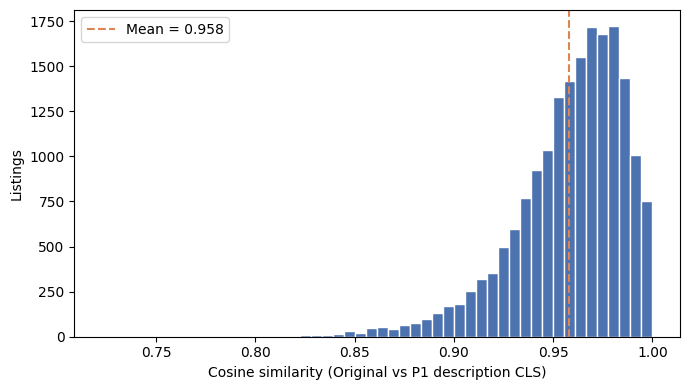

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims, bins=50, color='#4c72b0', edgecolor='white')
ax.axvline(sims.mean(), color='#dd8452', linestyle='--', label=f'Mean = {sims.mean():.3f}')
ax.set_xlabel('Cosine similarity (Original vs P1 description CLS)')
ax.set_ylabel('Listings')
ax.legend()
plt.tight_layout()
plt.savefig('cls_similarity.pdf', bbox_inches='tight')
plt.show()